# Post 06: When Is a Trajectory Long Enough to Trust?

This notebook is the presentation layer for the sixth tutorial. The reusable trajectory-length diagnostics, compact reduced-unit argon physical-observable check, and figure logic live in `src/kups_md_tutorials/`.

The goal is to distinguish raw frame count from effective sample count, uncertainty, and replica agreement, then apply the same review habit to a physical argon observable.


In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.figures import generate_post06_figures
from kups_md_tutorials.trajectory_length import load_trajectory_length_summary

## Configuration

The smoke and full profiles use a controlled correlated observable with a known equilibrium mean. This makes it possible to test warmup removal, autocorrelation, effective sample size, block uncertainty, and independent replica agreement directly. Both profiles also include a compact reduced-unit argon Langevin diagnostic that estimates potential energy per atom across independent replicas and trajectory-length checkpoints.


In [3]:
for profile in ["smoke", "full"]:
    print(f"--- {profile} ---")
    print(json.dumps(json.loads(Path(f"configs/post-06/{profile}.json").read_text()), indent=2))

--- smoke ---
{
  "post": "06",
  "profile": "smoke",
  "title": "When Is a Trajectory Long Enough to Trust?",
  "trajectory_length_experiment": {
    "true_mean": 0.5,
    "stationary_variance": 1.0,
    "correlation_time": 30.0,
    "equilibration_time": 120.0,
    "initial_bias": 2.5,
    "time_step": 1.0,
    "max_steps": 2500,
    "warmup_steps": 250,
    "sample_every": 2,
    "replica_count": 4,
    "seed": 2026071406,
    "checkpoints": [
      500,
      1000,
      2500
    ]
  },
  "argon_observable": {
    "repetitions": 2,
    "number_density": 0.85,
    "temperature": 0.7,
    "gamma": 1.0,
    "time_step": 0.002,
    "max_steps": 3000,
    "warmup_steps": 500,
    "sample_every": 10,
    "replica_count": 3,
    "seed": 2026071606,
    "checkpoints": [
      1000,
      2000,
      3000
    ],
    "coordination_cutoff": 1.5,
    "epsilon": 1.0,
    "sigma": 1.0,
    "cutoff": 2.5,
    "target_device": "cpu"
  }
}
--- full ---
{
  "post": "06",
  "profile": "full",
  "titl

## Committed Results

The summary reports naive standard error, autocorrelation-aware standard error, block standard error, replica standard error, and the conservative uncertainty used for review. For argon, the same checkpoint structure reports potential-energy-per-atom estimates, effective samples, autocorrelation-aware uncertainty, and replica spread.


In [4]:
summary = load_trajectory_length_summary(Path("results/post-06/full/trajectory_length_summary.json"))
for checkpoint in summary.checkpoints:
    print(
        checkpoint.checkpoint_steps,
        "mean=", round(checkpoint.mean_estimate, 4),
        "ESS=", round(checkpoint.effective_samples, 1),
        "naive SE=", round(checkpoint.naive_standard_error, 4),
        "conservative SE=", round(checkpoint.conservative_standard_error, 4),
        "95% half-width=", round(checkpoint.conservative_ci95_half_width, 4),
    )

argon = summary.argon_observable
if argon is not None:
    print("--- argon potential energy per atom ---")
    print("target device=", argon.target_device)
    print("runtime device=", argon.runtime_device)
    print("production GPU ready=", argon.production_gpu_ready)
    print("GPU blocking reason=", argon.gpu_blocking_reason)
    for checkpoint in argon.checkpoints:
        print(
            checkpoint.checkpoint_steps,
            "mean=", round(checkpoint.mean_potential_energy_per_atom, 4),
            "ESS=", round(checkpoint.effective_samples, 1),
            "autocorr SE=", round(checkpoint.autocorrelation_standard_error, 4),
            "replica SE=", round(checkpoint.replica_standard_error, 4),
            "conservative SE=", round(checkpoint.conservative_standard_error, 4),
        )


2000 mean= 0.4094 ESS= 148.9 naive SE= 0.0271 conservative SE= 0.1617 95% half-width= 0.317
6000 mean= 0.5108 ESS= 580.7 naive SE= 0.0112 conservative SE= 0.0571 95% half-width= 0.112
12000 mean= 0.4901 ESS= 996.8 naive SE= 0.0077 conservative SE= 0.0422 95% half-width= 0.0827
24000 mean= 0.4936 ESS= 2295.6 naive SE= 0.0054 conservative SE= 0.0208 95% half-width= 0.0408
--- argon potential energy per atom ---
target device= cuda_or_cpu_fallback
runtime device= jax:cpu;devices:cpu
production GPU ready= False
GPU blocking reason= target device requests CUDA/GPU, but generated artifact runtime was jax:cpu;devices:cpu
3000 mean= -5.4839 ESS= 34.9 autocorr SE= 0.0186 replica SE= 0.0304 conservative SE= 0.0304
6000 mean= -5.4841 ESS= 70.8 autocorr SE= 0.0139 replica SE= 0.0415 conservative SE= 0.0415
12000 mean= -5.4621 ESS= 114.8 autocorr SE= 0.0117 replica SE= 0.0479 conservative SE= 0.0479


## Figure

The full-profile figure is regenerated from committed compact outputs. The fourth panel is a reduced-unit argon physical-observable check: autocorrelation-adjusted uncertainty shrinks with more samples, while conservative replica spread remains visible.


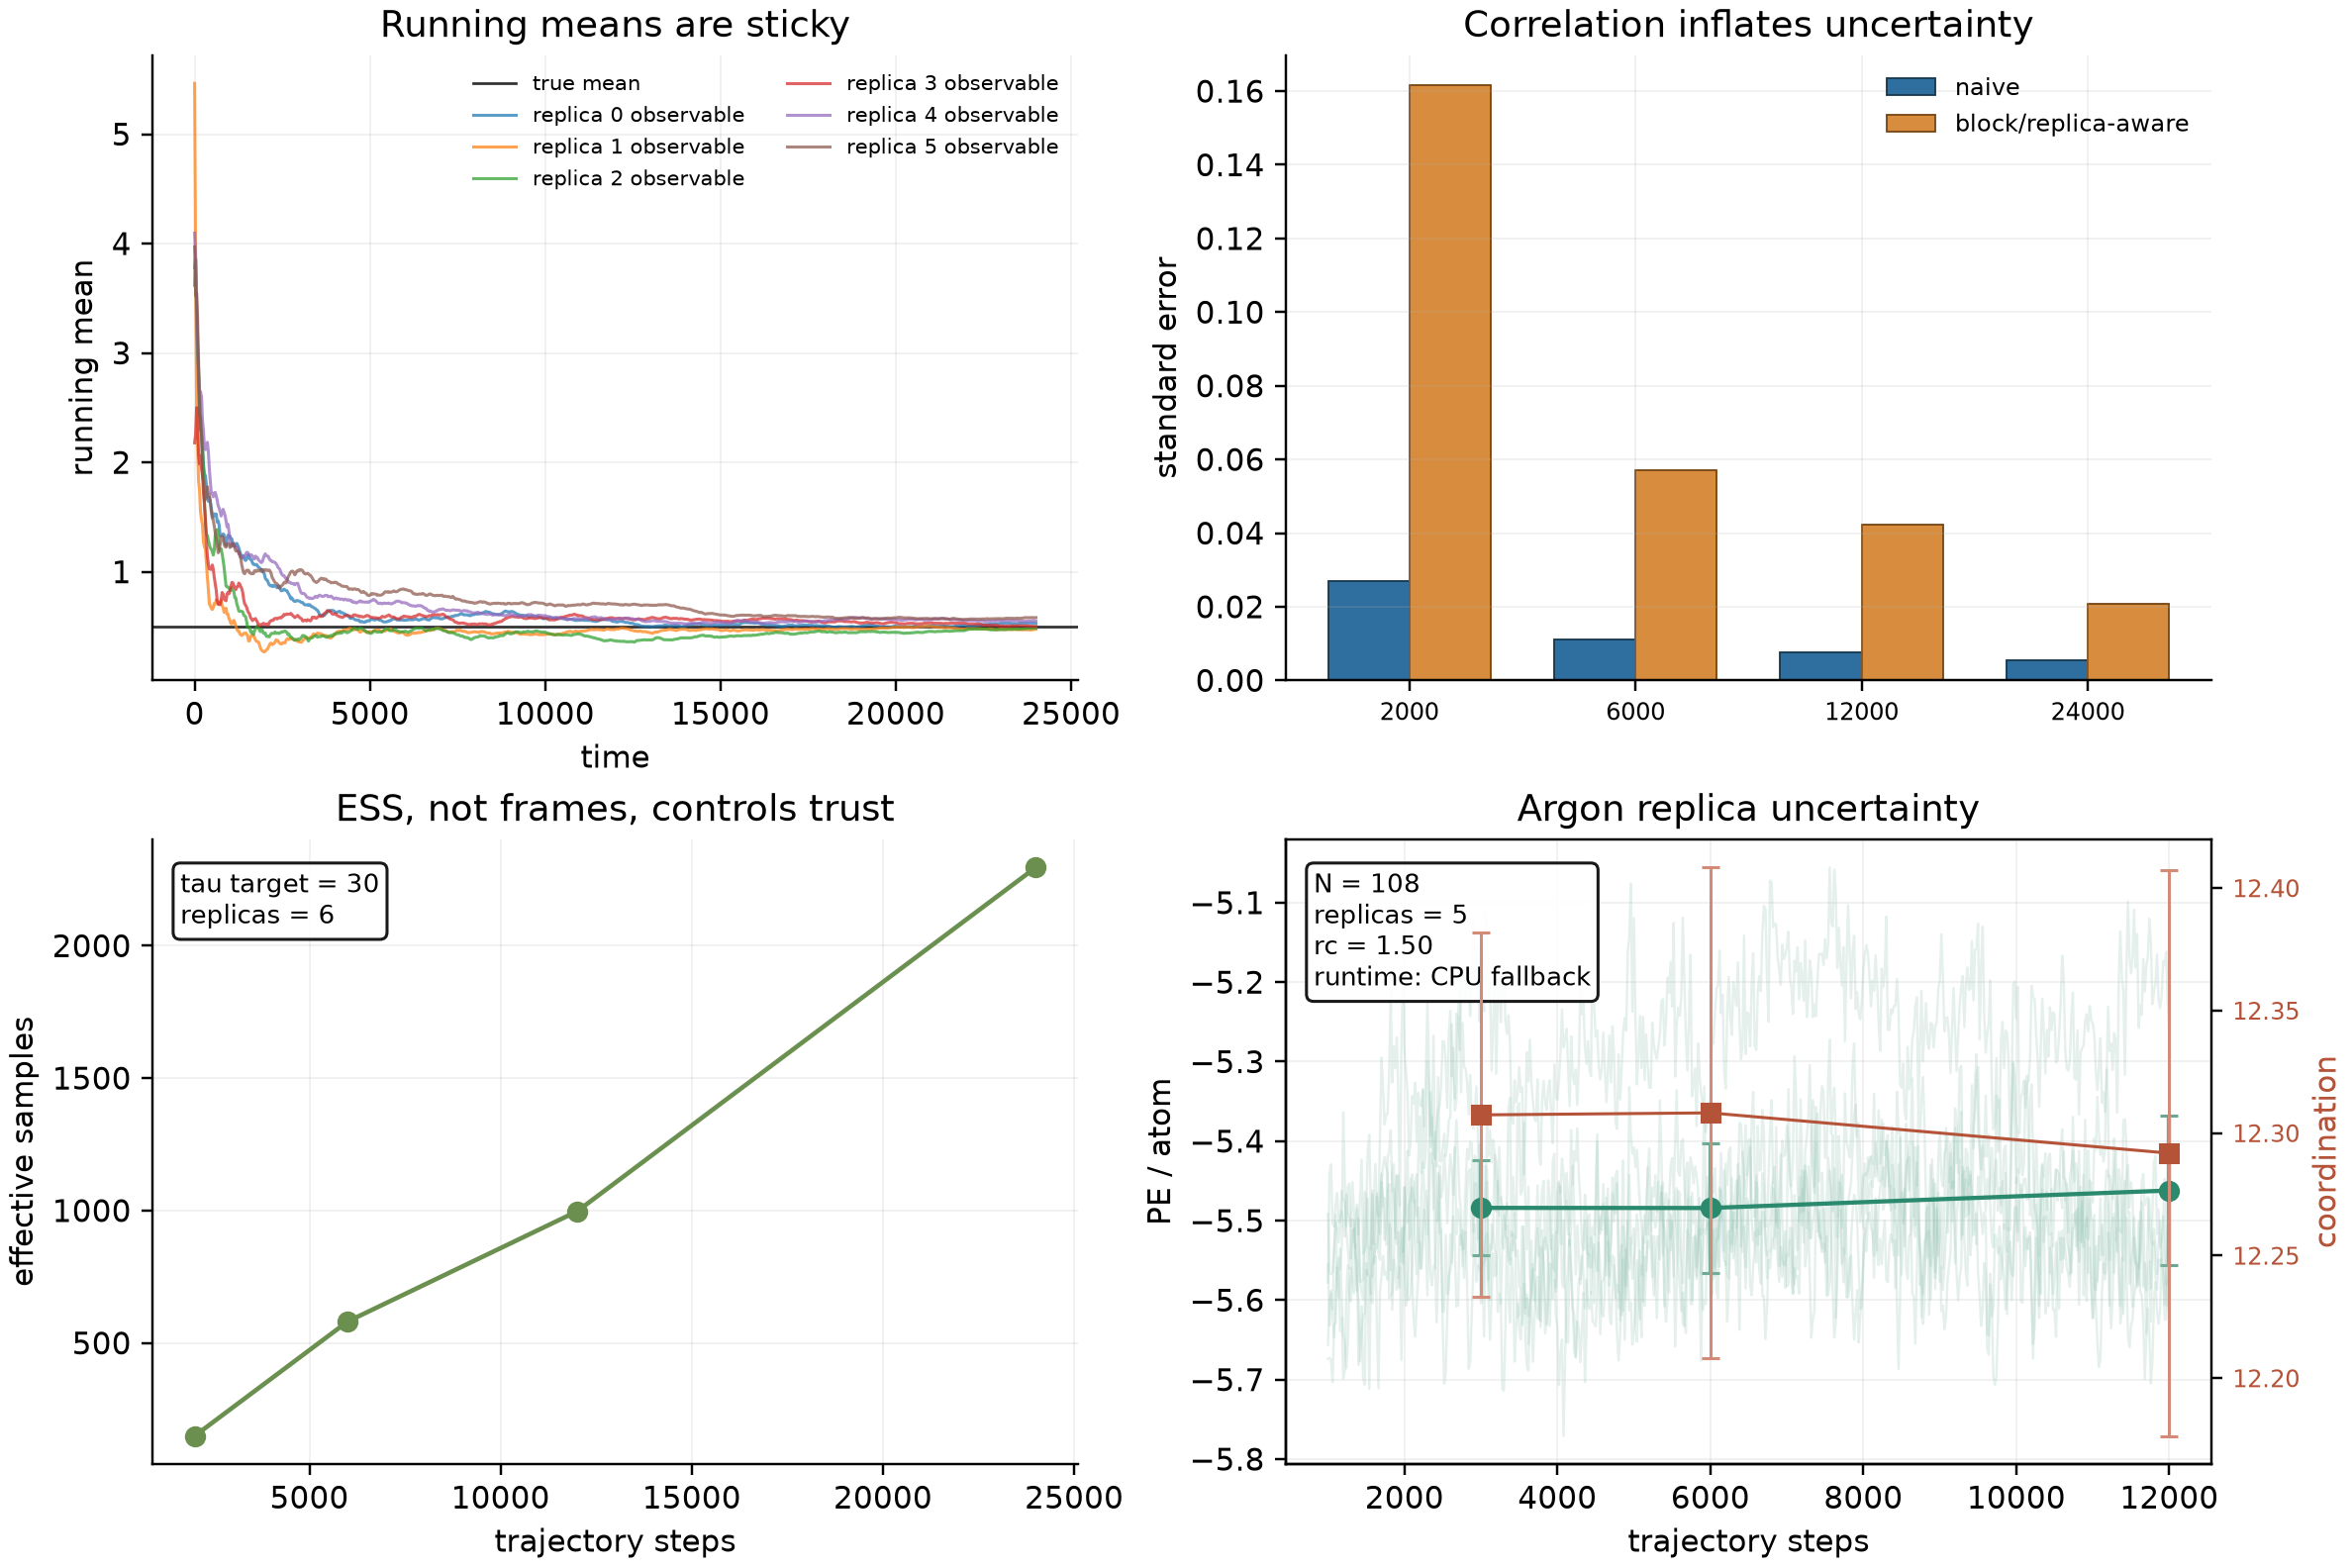

In [5]:
generate_post06_figures(
    result_dir=Path("results/post-06/full"),
    figure_dir=Path("figures/post-06"),
    snapshot_dir=Path("snapshots/post-06"),
    name="trajectory_length_diagnostics_full",
)
display(Image(filename="figures/post-06/trajectory_length_diagnostics_full.png"))